In [1]:
from misc import *
import constant

# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

no_ismuon_df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
df = no_ismuon_df[(no_ismuon_df["muplus_isMuon"] == True) & (no_ismuon_df["muminus_isMuon"] == True)]
df = df[df["J_psi_1S_PT"] < 1000]

In [2]:
def add_upsilon(ax, xS, scale=1, **kwargs):
    for i in xS:
        mass = eval(f"constant.UPSILON_{i}S_MASS")
        label = r"$M(\Upsilon\mathrm{(" + f"{i}" + r"S)})$"
        ax.axvline(mass*scale, color="k", linewidth=1.5, label=label, ls="--", **kwargs)

In [3]:
import vector

muplus_vector = vector.array(
    {
        "px": df["muplus_PX"]/1000,
        "py": df["muplus_PY"]/1000,
        "pz": df["muplus_PZ"]/1000,
        "mass": df["muplus_M"]/1000,
    }
)
muminus_vector = vector.array(
    {
        "px": df["muminus_PX"]/1000,
        "py": df["muminus_PY"]/1000,
        "pz": df["muminus_PZ"]/1000,
        "mass": df["muminus_M"]/1000,
    }
)

com_vector = muplus_vector + muminus_vector

pt_total = np.sqrt(com_vector.px**2 + com_vector.py**2)
log_pt_squared = np.log((pt_total)**2)


def pt_dimuon(df):
    px_muplus = (df["muplus_PT"]/1000) * np.cos(df["muplus_phi"])
    px_muminus = (df["muminus_PT"]/1000) * np.cos(df["muminus_phi"])
    py_muplus = (df["muplus_PT"]/1000) * np.sin(df["muplus_phi"])
    py_muminus = (df["muminus_PT"]/1000) * np.sin(df["muminus_phi"])

    return np.sqrt((px_muplus + px_muminus)**2 + (py_muplus + py_muminus)**2)


Histogram not saved to file


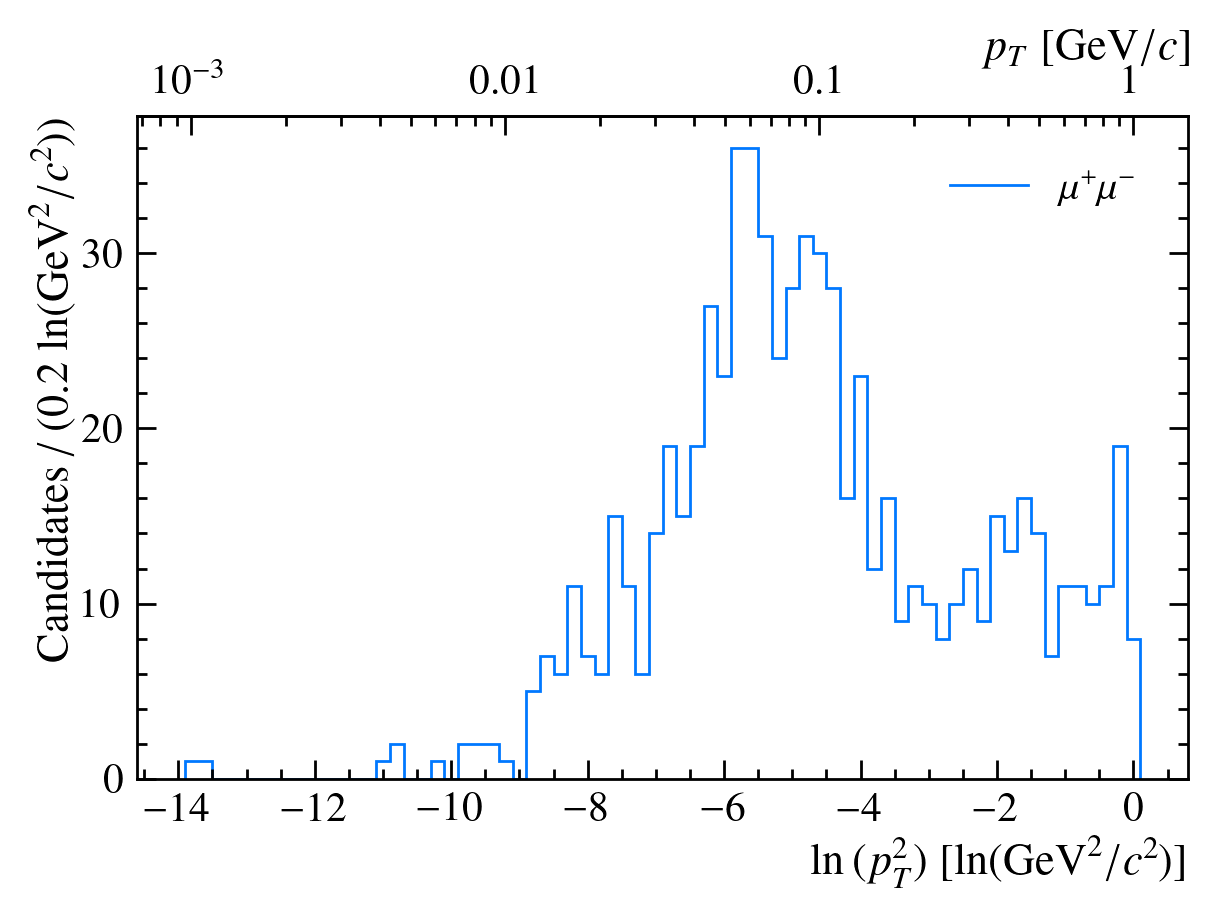

In [4]:
fig, ax = histogram_fig(
    [HistogramPlot(log_pt_squared, r"$\mu^+\mu^-$", bins=0.2)],
    False,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)"
)
add_log_pt_axis(ax, "GeV")
# ax.axvline(0, color="k", linewidth=1.5, label=r"$1 \ \mathrm{GeV}/c$", ls="--")
# ax.legend()

Histogram not saved to file


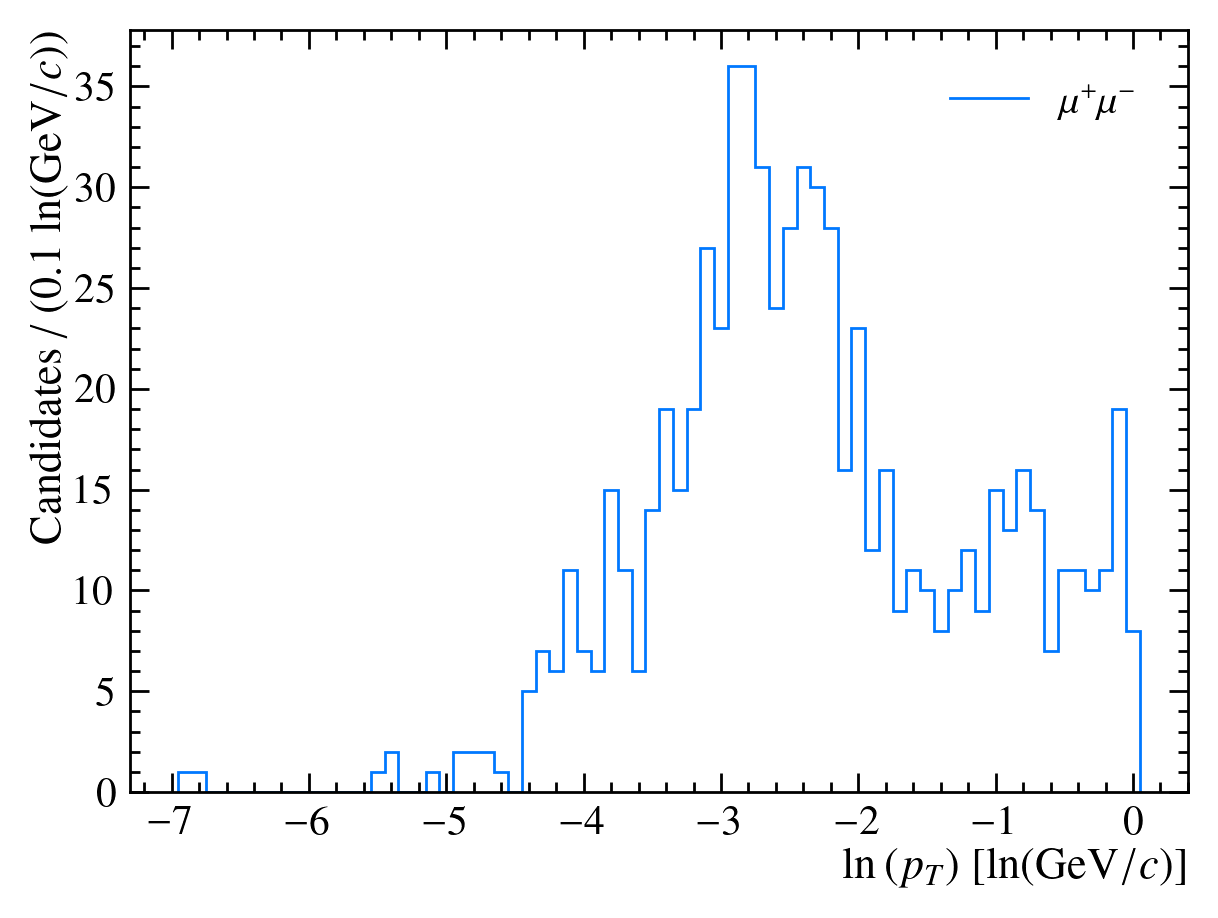

In [5]:
fig, ax = histogram_fig(
    [HistogramPlot(np.log(pt_total), r"$\mu^+\mu^-$", bins=0.1)],
    False,
    xlabel = r"$\ln{(p_T)}$",
    unit_tex = r"\ln(\mathrm{GeV}/c)"
)

Histogram not saved to file
0.9997648782102031


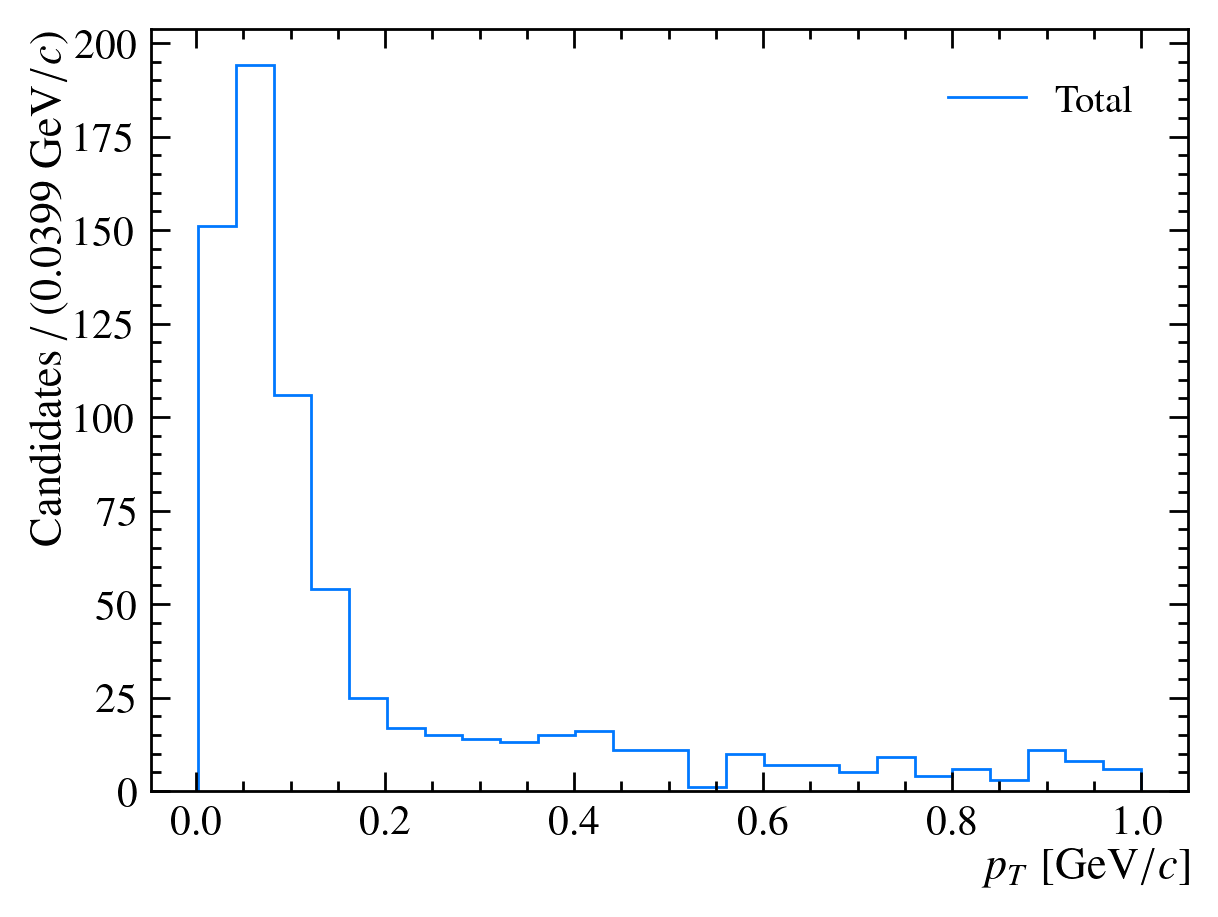

In [6]:
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_PT"]/1000, "Total")],
    False,
    xlabel = "$p_T$",
    unit_tex = r"\mathrm{GeV}/c"
)

print(max(df["J_psi_1S_PT"]/1000))

In [7]:
import json, pprint

json_path = "/dice/projects/LHCb/PbPb_MSCi/01_Fit_coherent_contributions/Fit_result.json"

with open(json_path, "r") as f:
    fit_result = json.load(f)

pprint.pprint(fit_result)

{'MC_Jpsi_coherent': {'frac': [0.2402276472568088,
                               0.2599988046948141,
                               0.03873097893863867,
                               0.01694354068303766,
                               0.4440990284267008],
                      'mu': [-7.075512226970559,
                             -5.127704047562978,
                             -8.713472842772589,
                             -3.4615742707220543,
                             -5.967428338191095],
                      'sigma': [1.1752959608067084,
                                0.525521968640623,
                                1.8269359166309118,
                                0.24639699182042782,
                                0.7782239242622648],
                      'yield_model': [367130.62272151,
                                      397346.1180028683,
                                      59191.05722729458,
                                      25894.157950192166,
       

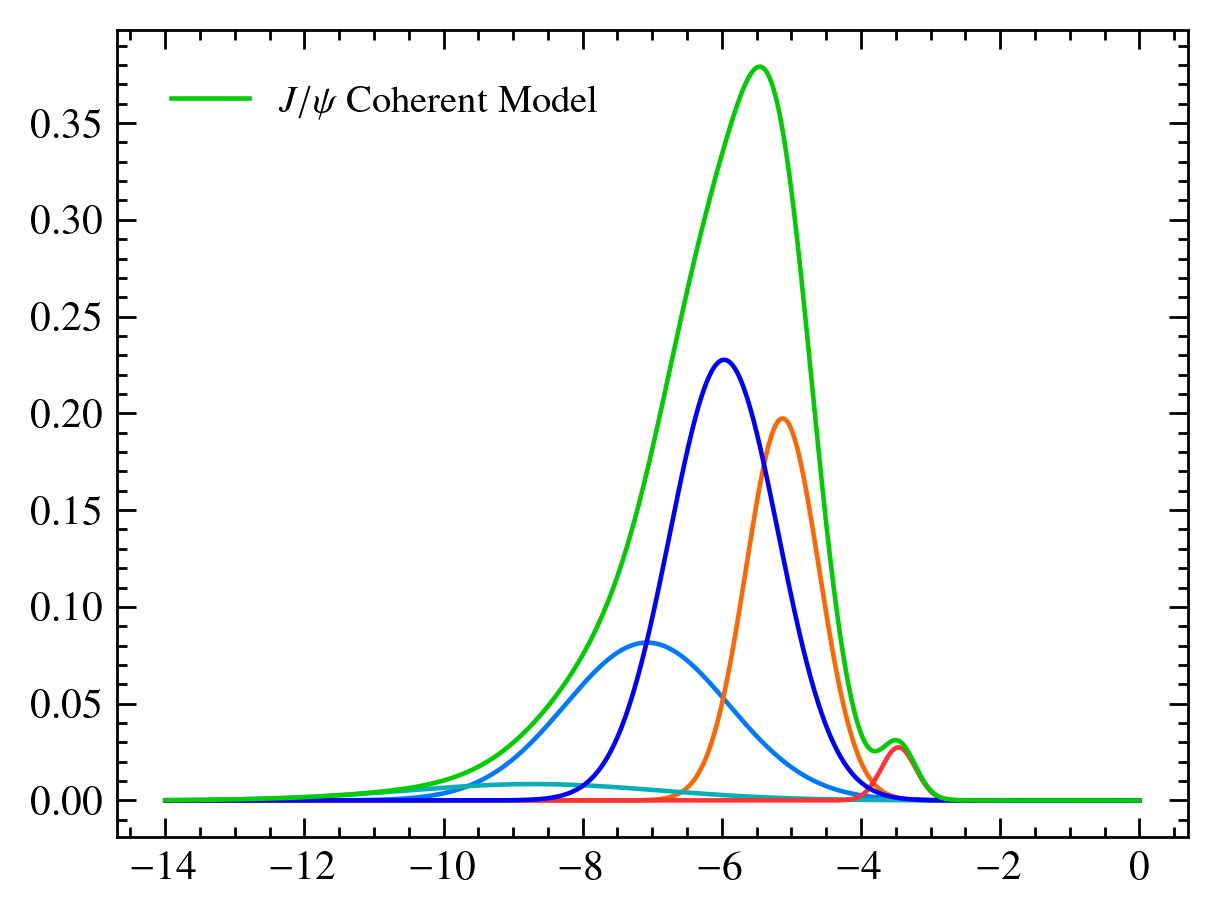

In [8]:
import scipy.stats

x = np.linspace(-14, 0, 1000)

fig, ax = plt.subplots()

MC_jpsi_coh = fit_result["MC_Jpsi_coherent"]
gaussians = []
for (mu, sigma, _yield_model, frac) in zip(MC_jpsi_coh["mu"], MC_jpsi_coh["sigma"], MC_jpsi_coh["yield_model"], MC_jpsi_coh["frac"]):
    y = scipy.stats.norm.pdf(x, mu, sigma)*frac
    gaussians.append(y)
    ax.plot(x, y)

ax.plot(x, sum(gaussians), label=r"$J/\psi$ Coherent Model")
ax.legend()



In [9]:
import zfit

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-03-01 01:59:13.449064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740794353.464860 2704320 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740794353.469979 2704320 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [10]:

# class GaussSum(zfit.pdf.BasePDF):
#     def __init__(self, obs: list, mus: list, sigmas: list, fracs: list, name="SumOfGaussians"):
#         gaussians = []
#         for (mu, sigma, frac) in zip(mus, sigmas, fracs):
#             gaussians.append(zfit.pdf.Gauss(obs=obs, mu=mu, sigma=sigma))

#         self.model = zfit.pdf.SumPDF(gaussians, fracs[:-1])

#         super().__init__(obs=obs, name=name)

def gauss_sum(obs, mus, sigmas, fracs):
    gaussians = []
    for (mu, sigma, frac) in zip(mus, sigmas, fracs):
        gaussians.append(zfit.pdf.Gauss(obs=obs, mu=mu, sigma=sigma))

    return zfit.pdf.SumPDF(gaussians, fracs[:-1])

observables = {
    "lnpt2": zfit.Space("lnpt2", -14, 0),
    "M": zfit.Space("M", 9, 20),
}
data = {
    "lnpt2": zfit.data.from_numpy(array=(log_pT2(df["J_psi_1S_PT"]/1e3)).to_numpy(), obs=observables["lnpt2"]),
    "M": zfit.data.from_numpy(array=(df["J_psi_1S_M"]/1e3).to_numpy(), obs=observables["M"])
}
yields = {
    "Jpsi_coh_Nsig": zfit.Parameter("Jpsi_coh_Nsig", 50),
    # "Jpsi_incoh_Nsig": zfit.Parameter("Jpsi_incoh_Nsig", 100),
    "Nbkg": zfit.Parameter("Nbkg", 650)
}
pdfs = {
    "Jpsi_coh_lnpt2": gauss_sum(obs=observables["lnpt2"], mus=MC_jpsi_coh["mu"], sigmas=MC_jpsi_coh["sigma"], fracs=MC_jpsi_coh["frac"]).create_extended(yields["Jpsi_coh_Nsig"]),

    "Jpsi_coh_M": zfit.pdf.Gauss(obs=observables["M"], mu=constant.UPSILON_1S_MASS/1e3, sigma=zfit.Parameter("Jpsi_coh_M_sigma", 53.9/1e3, floating=False)).create_extended(yields["Jpsi_coh_Nsig"]),
    # "Jpsi_incoh_M": zfit.pdf.Gauss(obs=observables["M"], mu=constant.UPSILON_1S_MASS, sigma=zfit.Parameter("Jpsi_incoh_M_sigma", 1e-3)),
    "bkg_M": zfit.pdf.Exponential(obs=observables["M"], lambda_=zfit.Parameter("bkg_M_lambda", -0.4)).create_extended(yields["Nbkg"])
}


2025-03-01 01:59:17.694708: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-03-01 01:59:17.694859: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 555.42.6 does not match DSO version 570.86.15 -- cannot find working devices in this configuration


/tmp/ipykernel_2704320/2986057081.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.linspace(float(kde.space.lower), float(kde.space.upper), 500)


Histogram not saved to file


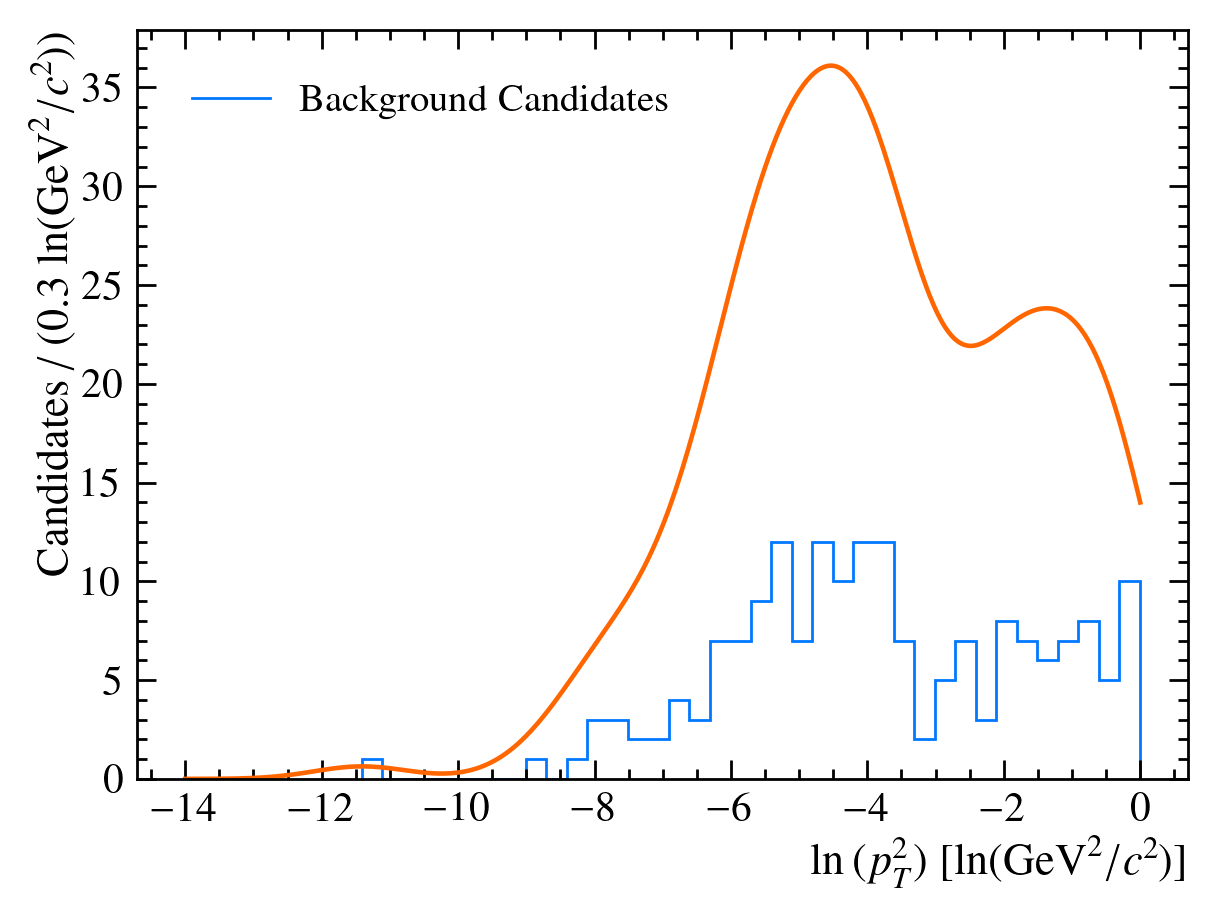

In [11]:
background_df = df[(df["J_psi_1S_M"] > 12e3) & (df["J_psi_1S_M"] < 20e3)]

bkg_data = zfit.data.from_numpy(array=(log_pT2(background_df["J_psi_1S_PT"]/1e3)).to_numpy(), obs=observables["lnpt2"])
kde = zfit.pdf.KDE1DimExact(obs=observables["lnpt2"], data=bkg_data)

pdfs["bkg_lnpt2"] = kde
pdfs["bkg_lnpt2"].set_yield(yields["Nbkg"])

x = np.linspace(float(kde.space.lower), float(kde.space.upper), 500)
bin_width = 0.3

fig, ax = histogram_fig(
    [HistogramPlot(np.log((background_df["J_psi_1S_PT"]/1e3)**2), "Background Candidates", bins=bin_width)],
    False,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)",
)
ax.plot(x, kde.ext_pdf(x)*bin_width, label="Background KDE")


In [ ]:
mass_model = zfit.pdf.SumPDF(pdfs=[pdfs["Jpsi_coh_M"], pdfs["bkg_M"]])
# incoh_model = zfit.pdf.ProductPDF(pdfs=[pdfs["Jpsi_coh_M"], pdfs["Jpsi_coh_lnpt2"]]).create_extended(yields["Jpsi_coh_Nsig"])
lnpt2_model = zfit.pdf.SumPDF(pdfs=[pdfs["Jpsi_coh_lnpt2"], pdfs["bkg_lnpt2"]])

In [13]:
# nll = zfit.loss.ExtendedUnbinnedNLL(model=[lnpt2_model, mass_model], data=[data["lnpt2"],data["M"]])
nll = zfit.loss.ExtendedUnbinnedNLL(model=[mass_model, lnpt2_model], data=[data["M"],data["lnpt2"]])

minimizer = zfit.minimize.Minuit()
minimum = minimizer.minimize(nll)
minimum.hesse()

print(minimum)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_19, Composed_autoparam_20], <zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_22, Composed_autoparam_23]] data=[<zfit.Data: Data obs=('M',) shape=(699, 1)>, <zfit.Data: Data obs=('lnpt2',) shape=(719, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═══════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │  edm  │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═══════╪══════════════════════════════╡
│  True   │    True     │      False       │ 5e-06 │          2851.05 |  10020.72 │
╘═════════╧═════════════╧══════════════════╧═══════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
Jpsi_coh_Nsig             59.4187  +/-      11       False
Nbk

Histogram not saved to file


/tmp/ipykernel_2704320/1441026966.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.linspace(float(lnpt2_model.space.lower), float(lnpt2_model.space.upper), 500)


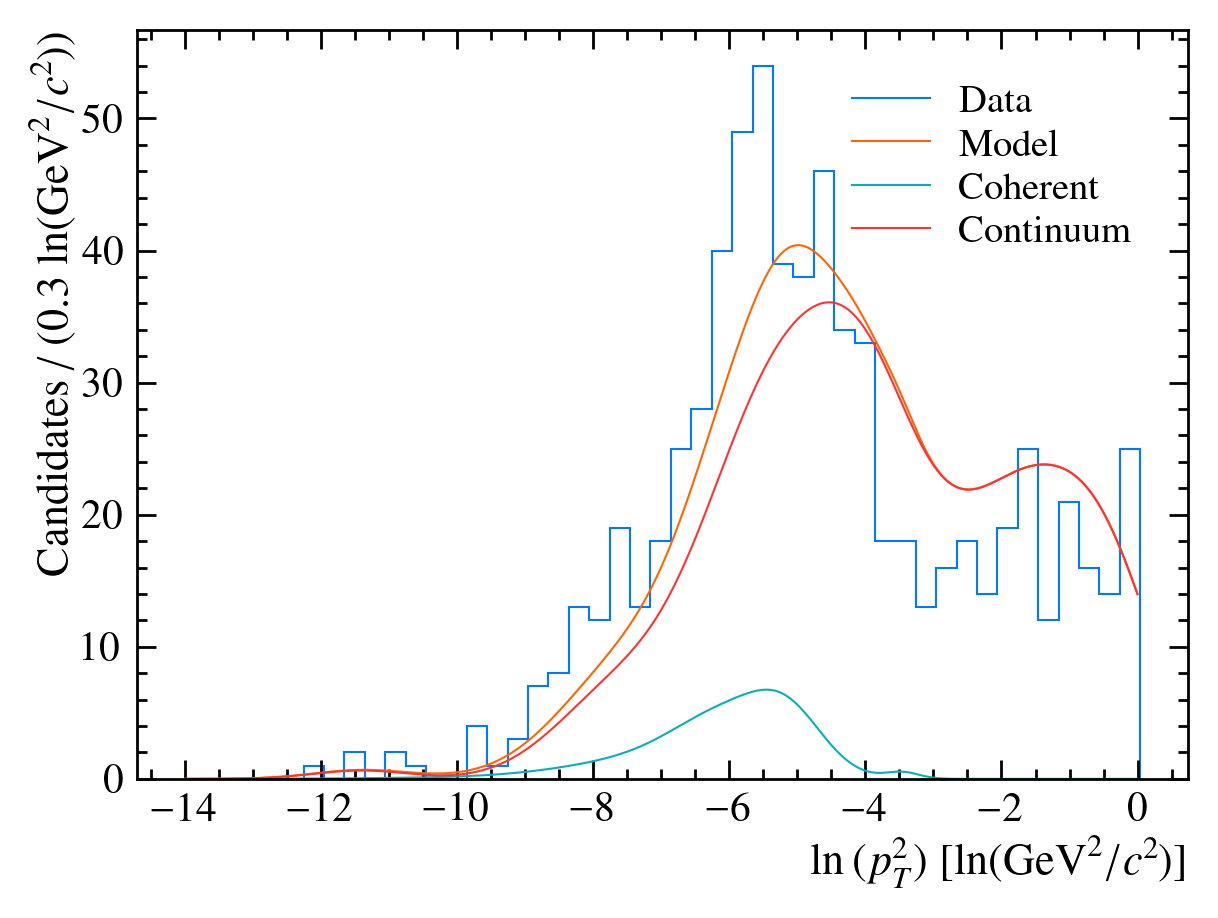

In [ ]:
bin_width = 0.3
fig, ax = histogram_fig(
    [HistogramPlot(log_pT2(df["J_psi_1S_PT"]/1e3), "Data", bins=bin_width, linewidth=1.5, error=True)],
    False,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)",
)
x = np.linspace(float(lnpt2_model.space.lower), float(lnpt2_model.space.upper), 500)
ax.plot(x, lnpt2_model.ext_pdf(x)*bin_width, label="Model", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_lnpt2"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_lnpt2"].ext_pdf(x)*bin_width, label="Continuum", linewidth=1.5)
ax.legend()

Histogram not saved to file


/tmp/ipykernel_2704320/1167953568.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.linspace(float(mass_model.space.lower), float(mass_model.space.upper), 500)


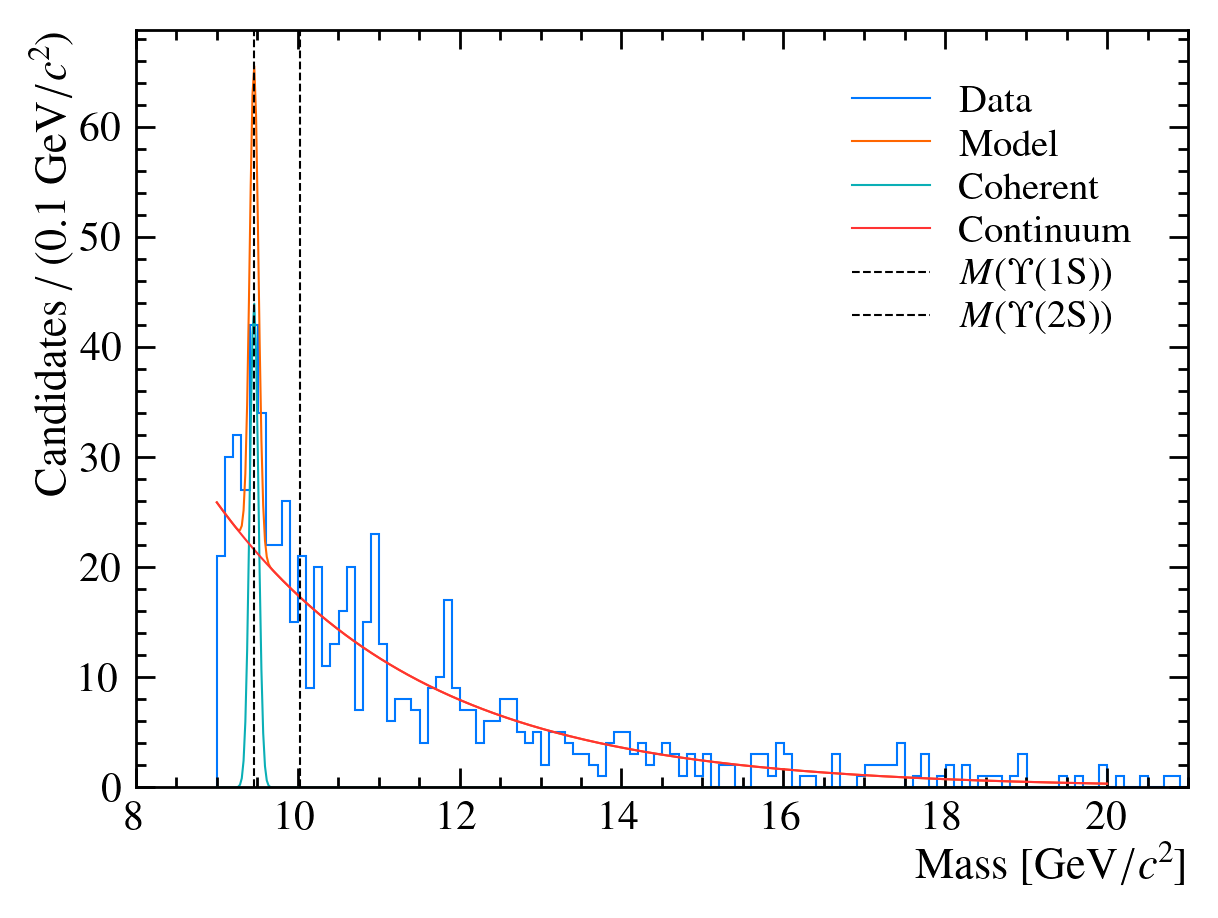

In [15]:
bin_width = 100/1e3
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"]/1e3, "Data", bins=bin_width, linewidth=1.5)],
    False,
    xlabel = r"Mass",
    unit_tex = r"\mathrm{GeV}/c^2",
    xlim=[8, 21]
)

x = np.linspace(float(mass_model.space.lower), float(mass_model.space.upper), 500)
ax.plot(x, mass_model.ext_pdf(x)*bin_width, label="Model", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_M"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_M"].ext_pdf(x)*bin_width, label="Continuum", linewidth=1.5)
add_upsilon(ax, scale=1/1000, xS=range(1,3))
ax.legend()

Histogram not saved to file


/tmp/ipykernel_2704320/4217324388.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.linspace(float(mass_model.space.lower), float(mass_model.space.upper), 1000)


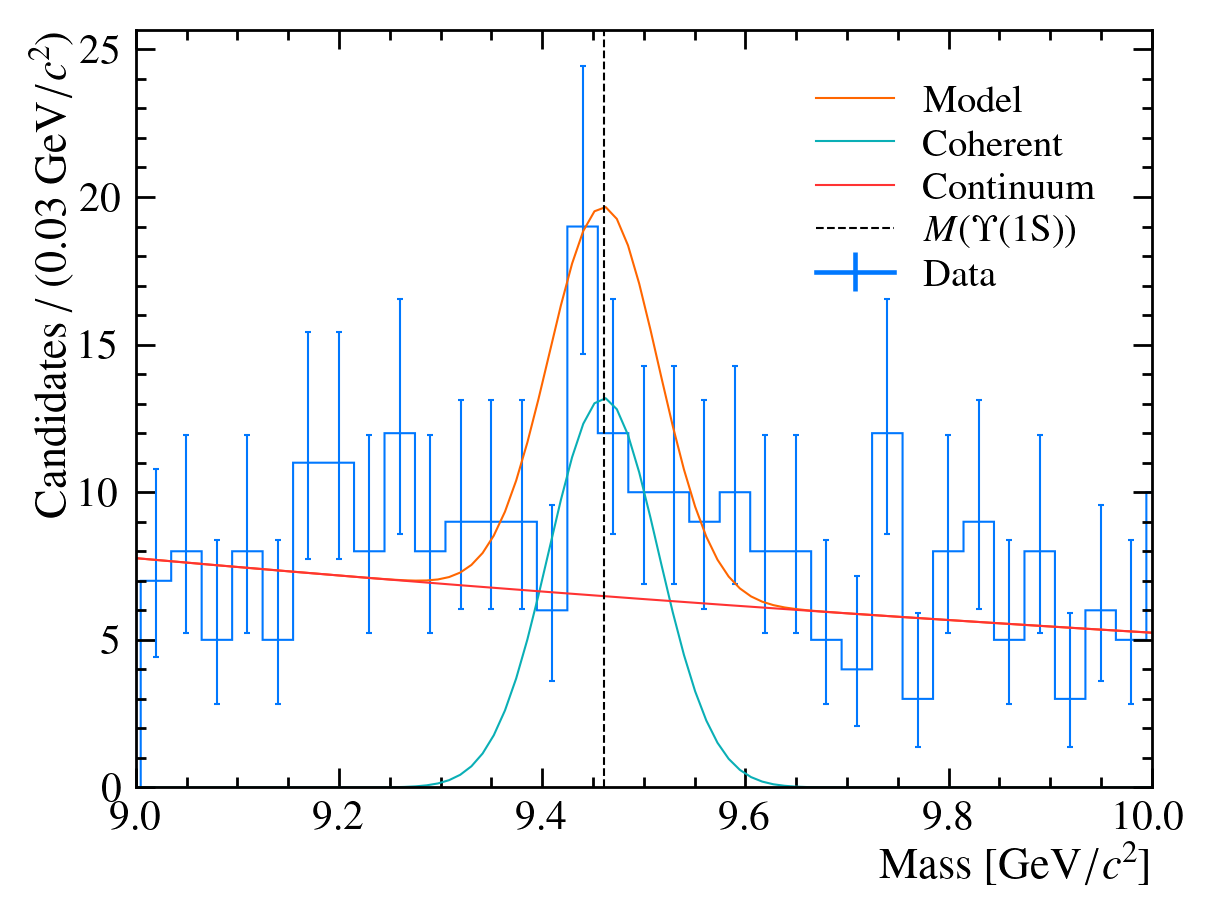

In [16]:
bin_width = 30/1e3
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"]/1e3, "Data", bins=bin_width, linewidth=1.5, error=True)],
    False,
    xlabel = r"Mass",
    unit_tex = r"\mathrm{GeV}/c^2",
    xlim=[9, 10]
)

x = np.linspace(float(mass_model.space.lower), float(mass_model.space.upper), 1000)
ax.plot(x, mass_model.ext_pdf(x)*bin_width, label="Model", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_M"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_M"].ext_pdf(x)*bin_width, label="Continuum", linewidth=1.5)
add_upsilon(ax, scale=1/1000, xS=range(1,2))
ax.legend()


Histogram not saved to file


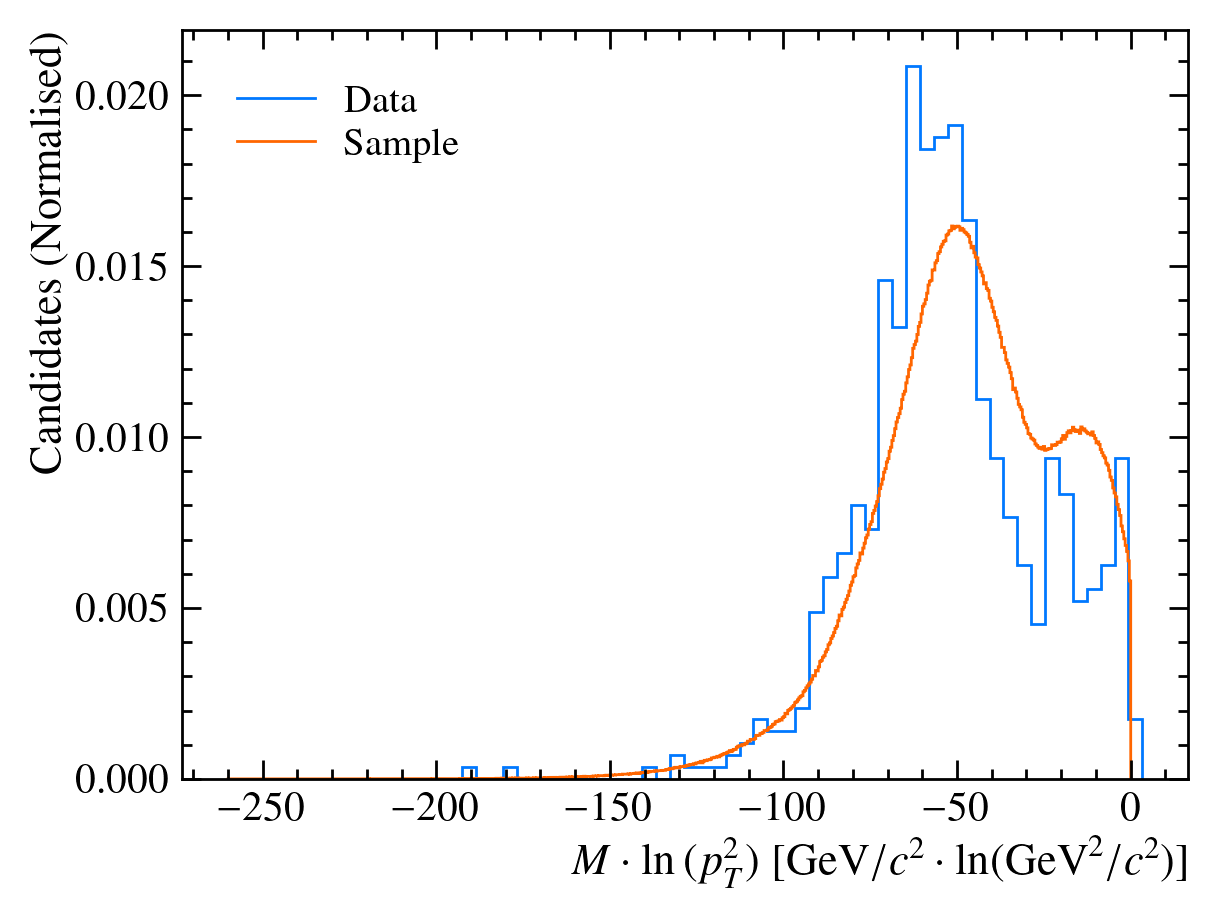

In [18]:
a = mass_model.sample(1e7).to_numpy()
b = lnpt2_model.sample(1e7).to_numpy()

bin_width = 4
fig, ax = histogram_fig(
    [HistogramPlot((df["J_psi_1S_M"]/1e3)*log_pT2(df["J_psi_1S_PT"]/1e3), "Data", bins=bin_width),
     HistogramPlot(a*b, "Sample", bins=bin_width/10)],
    False,
    xlabel = r"$M \cdot \ln{(p_T^2)}$",
    unit_tex = r"\mathrm{GeV}/c^2 \cdot \ln(\mathrm{GeV}^2/c^2)",
    density=True
)